In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

sns.set_style("whitegrid")

# Load data
credits = pd.read_csv('/Users/mugil/Code Files/Visual Studio Code/Data Analyst Project/3. Netflix Content Analysis/dataset/credits.csv', encoding='ISO-8859-1')
titles = pd.read_csv('/Users/mugil/Code Files/Visual Studio Code/Data Analyst Project/3. Netflix Content Analysis/dataset/titles.csv', encoding='ISO-8859-1')

In [17]:
# 2. CLEANING
titles.drop_duplicates(inplace=True)
credits.drop_duplicates(inplace=True)

titles['age_certification'] = titles['age_certification'].fillna('Not Rated')
titles['genres'] = titles['genres'].fillna('[]')
titles['production_countries'] = titles['production_countries'].fillna('[]')
titles['seasons'] = titles['seasons'].fillna(0)
titles['runtime'] = titles['runtime'].fillna(0)

def parse_list_col(x):
    try:
        val = ast.literal_eval(x)
        return val if isinstance(val, list) else [val]
    except (ValueError, SyntaxError):
        return []

titles['genres_list'] = titles['genres'].apply(parse_list_col)
titles['countries_list'] = titles['production_countries'].apply(parse_list_col)

titles = titles[titles['release_year'].notna()]
titles['release_year'] = titles['release_year'].astype(int)

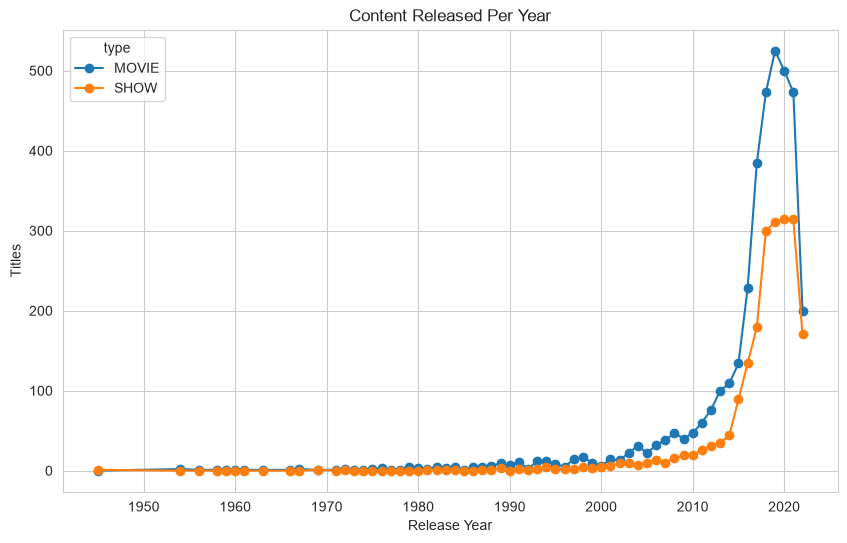

In [18]:
# 3. Line chart: Content per year (Movies vs TV Shows)
year_type = titles.groupby(['release_year', 'type']).size().unstack(fill_value=0)
year_type.plot(marker='o', figsize=(10, 6), title="Content Released Per Year")
plt.xlabel("Release Year"); plt.ylabel("Titles"); plt.show()

/var/folders/jh/zb3955zj477878gy9hjj1b3m0000gn/T/ipykernel_44119/46004408.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")


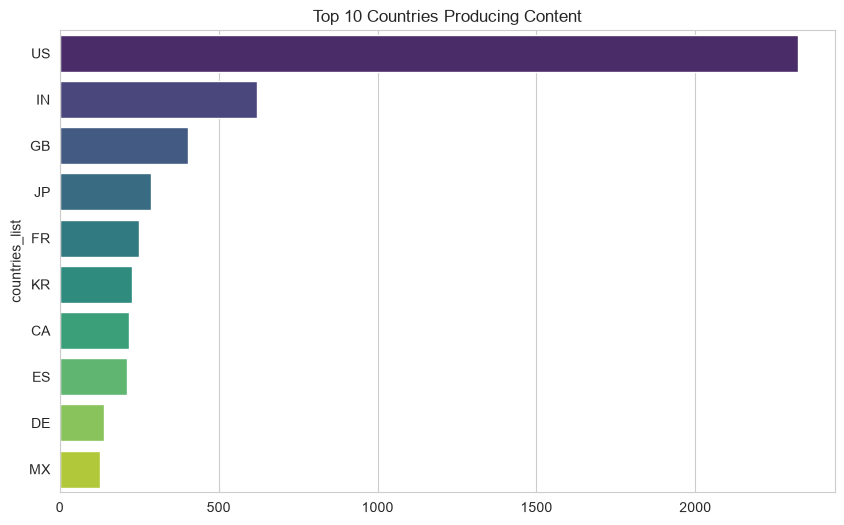

In [21]:
# 4. Bar chart: Top 10 countries
countries_exploded = titles.explode('countries_list')
countries_exploded = countries_exploded[countries_exploded['countries_list'] != '']
top_countries = countries_exploded['countries_list'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette="viridis")
plt.title("Top 10 Countries Producing Content"); plt.show()

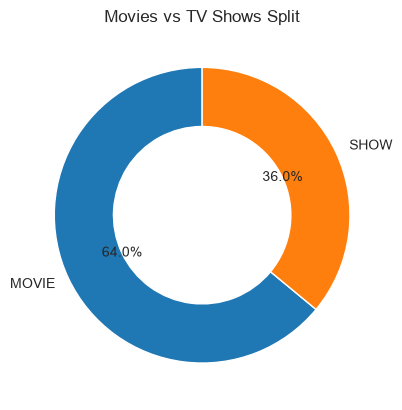

In [22]:
# 5. Pie/Donut: Movies vs TV Shows
type_counts = titles['type'].value_counts()
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
        startangle=90, wedgeprops={'width': 0.4})
plt.title("Movies vs TV Shows Split"); plt.show()

/var/folders/jh/zb3955zj477878gy9hjj1b3m0000gn/T/ipykernel_44119/2955454376.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette="magma")


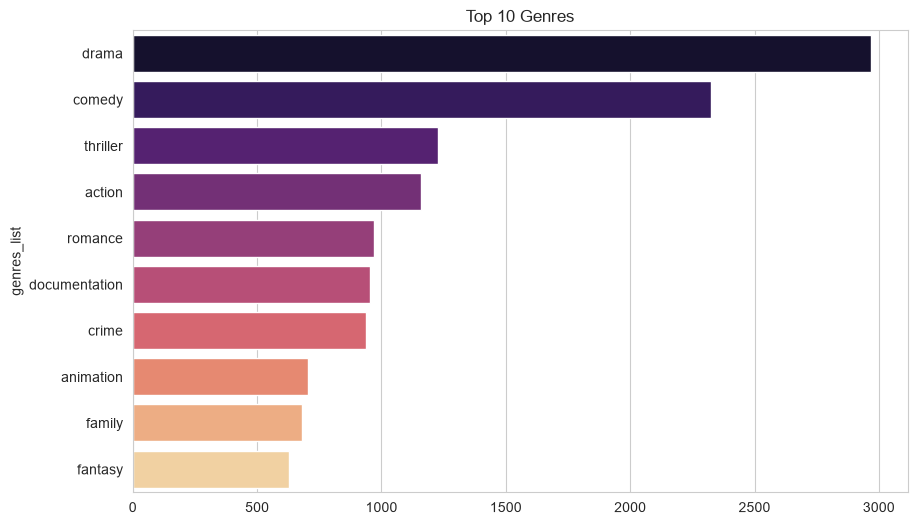

In [23]:
# 6. Bar chart: Top genres
genres_exploded = titles.explode('genres_list')
genres_exploded = genres_exploded[genres_exploded['genres_list'] != '']
top_genres = genres_exploded['genres_list'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette="magma")
plt.title("Top 10 Genres"); plt.show()

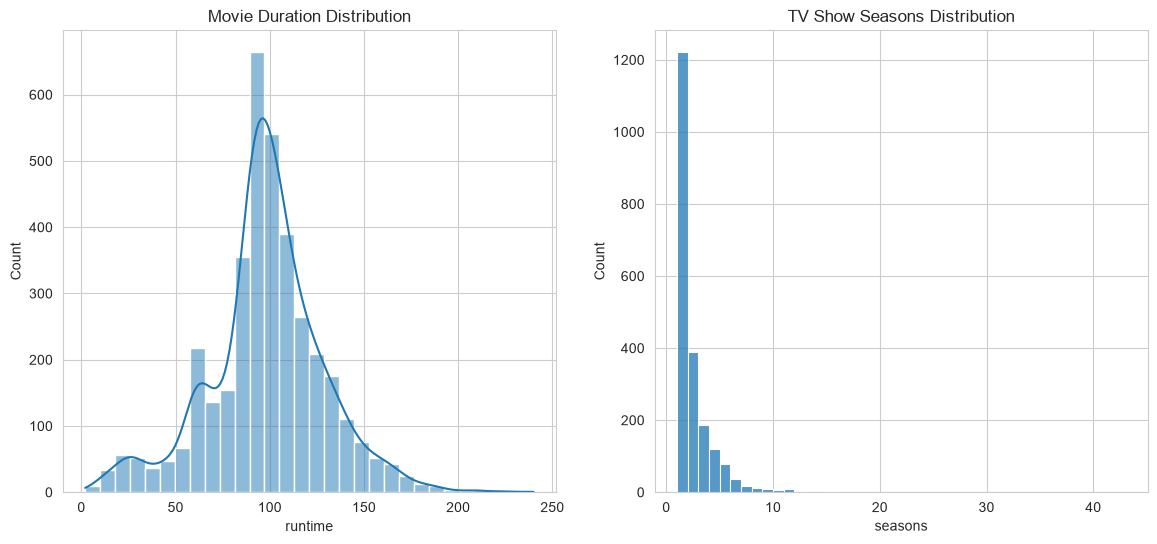

In [24]:
# 7. Histogram: Movie durations & TV seasons
movies = titles[titles['type'] == 'MOVIE']
shows = titles[titles['type'] == 'SHOW']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.histplot(movies[movies['runtime'] > 0]['runtime'], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Movie Duration Distribution")
sns.histplot(shows[shows['seasons'] > 0]['seasons'], bins=range(1, int(shows['seasons'].max())+2), ax=axes[1])
axes[1].set_title("TV Show Seasons Distribution")
plt.show()

/var/folders/jh/zb3955zj477878gy9hjj1b3m0000gn/T/ipykernel_44119/2596331894.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="coolwarm")


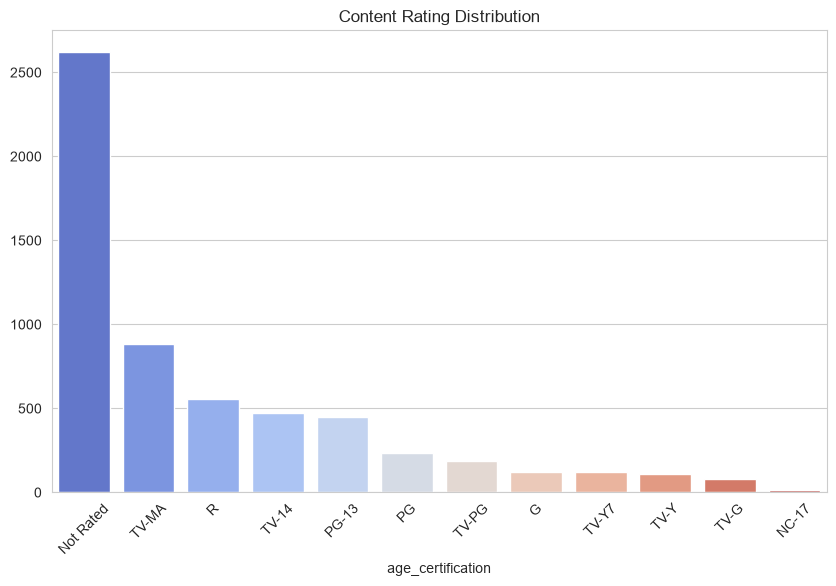

In [25]:
# 8. Bar chart: Content rating distribution
rating_counts = titles['age_certification'].value_counts()
plt.figure(figsize=(10,6))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="coolwarm")
plt.title("Content Rating Distribution"); plt.xticks(rotation=45); plt.show()

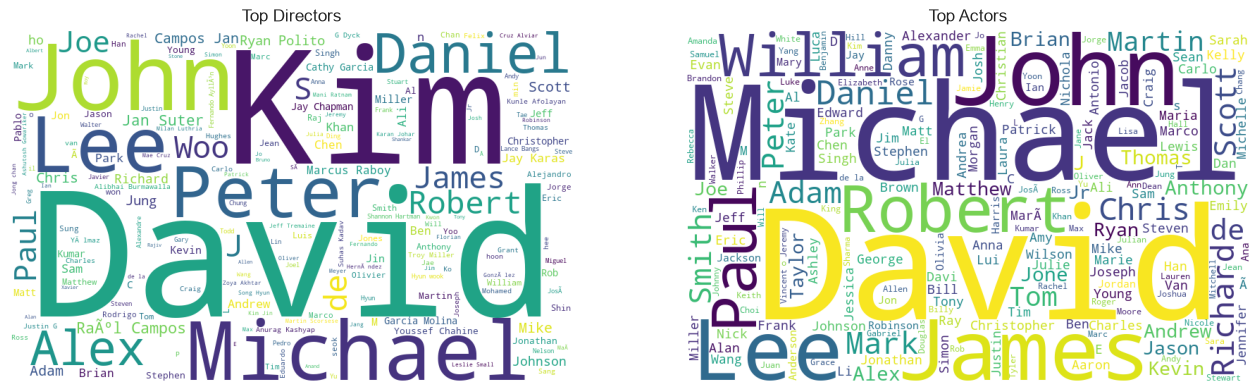

In [27]:
# 9. Word cloud: Top directors/actors (optional)
from wordcloud import WordCloud

directors = credits[credits['role'].str.upper() == 'DIRECTOR']['name']
actors = credits[credits['role'].str.upper() == 'ACTOR']['name']

director_text = " ".join(directors.dropna().astype(str))
actor_text = " ".join(actors.dropna().astype(str))

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
axes[0].imshow(WordCloud(width=800, height=500, background_color='white').generate(director_text))
axes[0].set_title("Top Directors"); axes[0].axis('off')
axes[1].imshow(WordCloud(width=800, height=500, background_color='white').generate(actor_text))
axes[1].set_title("Top Actors"); axes[1].axis('off')
plt.show()

In [28]:
# 10. Key insights
print("TV-MA share:", round(rating_counts.get('TV-MA', 0) / rating_counts.sum() * 100, 2), "%")
print("Peak release year:", year_type.sum(axis=1).idxmax())
print("Top 3 countries:\n", top_countries.head(3))

TV-MA share: 15.09 %
Peak release year: 2019
Top 3 countries:
 countries_list
US    2323
IN     622
GB     404
Name: count, dtype: int64
